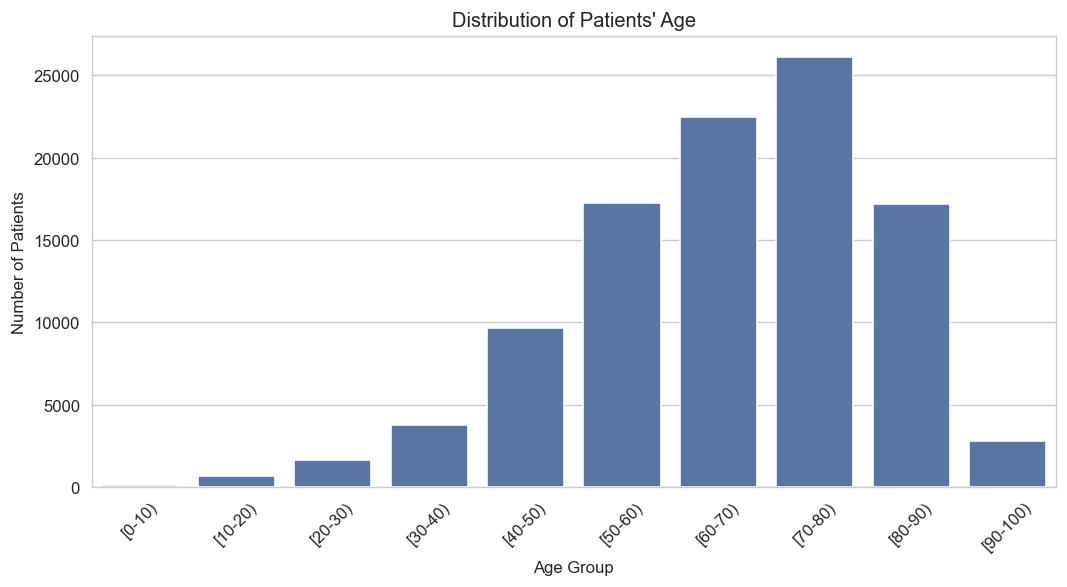

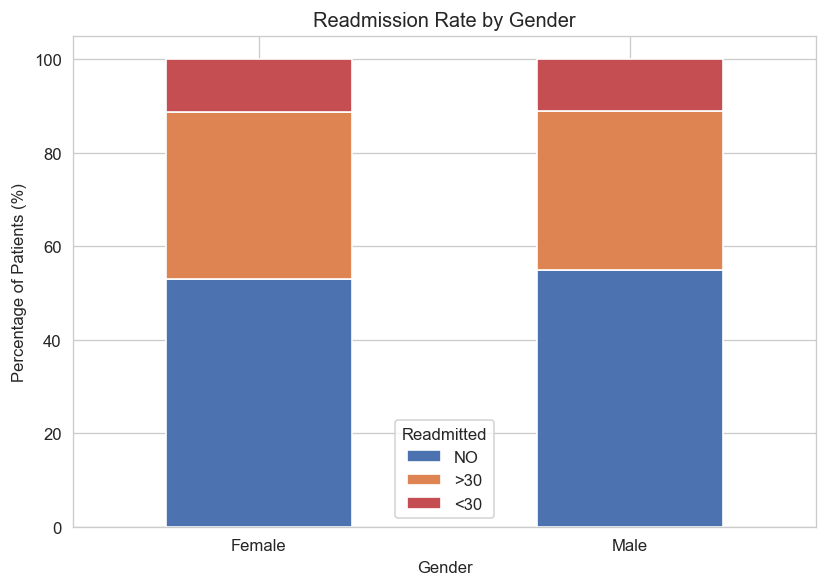

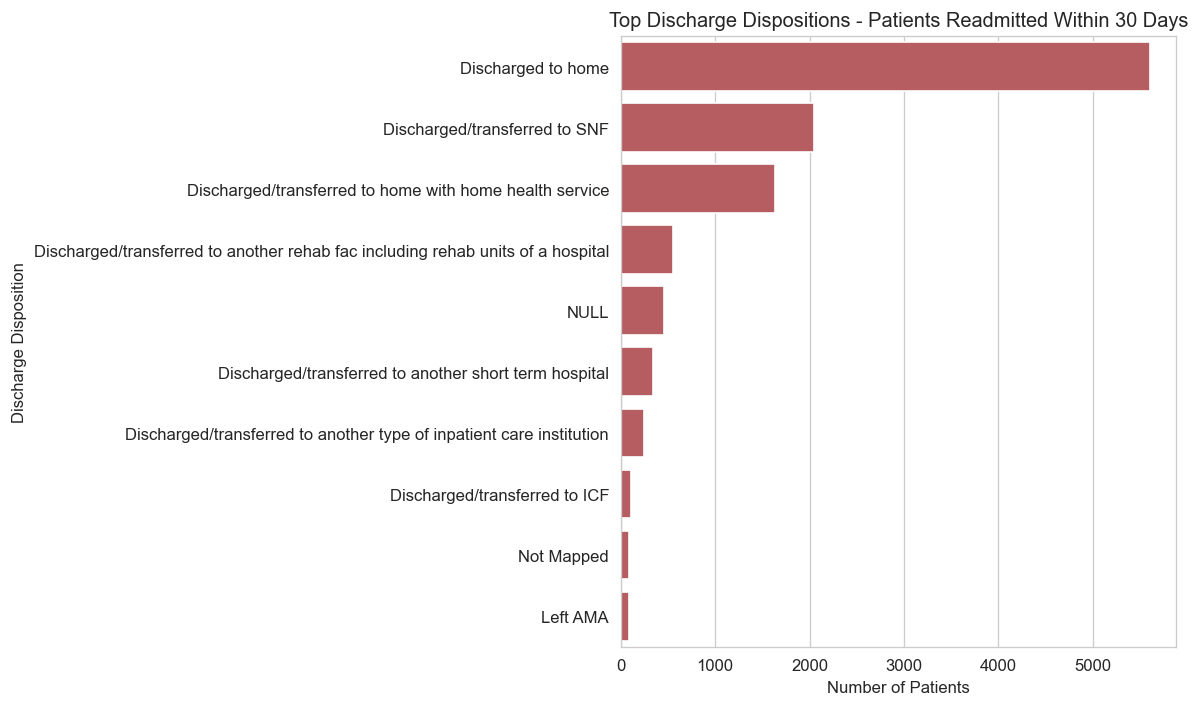

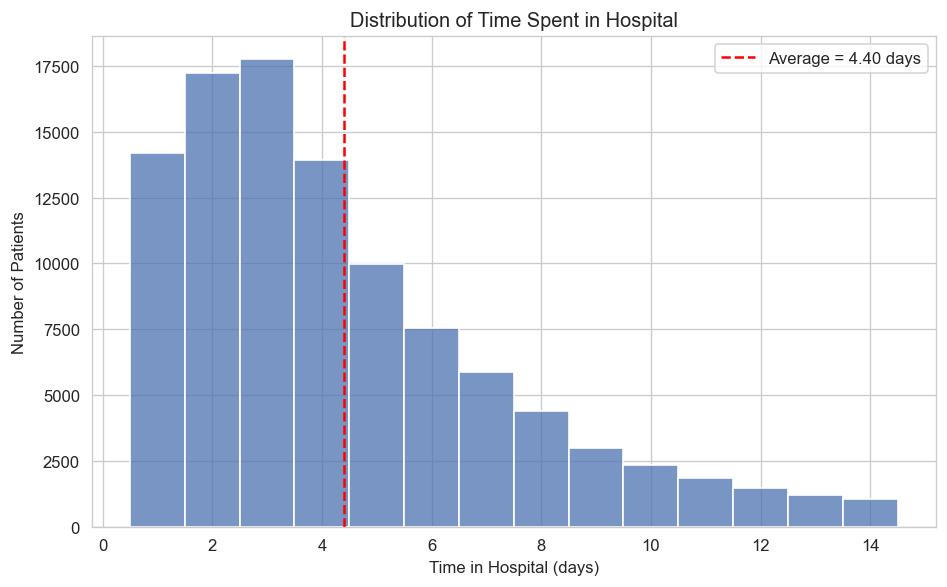

=== SUMMARY ===

1. Age distribution (counts):
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

2. Readmission distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
({'NO': 53.9, '>30': 34.9, '<30': 11.2})

3. Readmission rate by gender (%):
readmitted    NO   >30   <30
gender                      
Female      53.1  35.7  11.2
Male        54.9  34.1  11.1

4. Top discharge dispositions for <30 day readmits:
discharge_label
Discharged to home                                                                 5602
Discharged/transferred to SNF                                                      2046
Discharged/transferred to home with home health service                            1638
Discharged/transferred to another rehab fac including rehab units of a hospital     552
NULL                   

In [4]:
"""
Descriptive Analytics & Visualization
Dataset: Diabetes.csv (UCI Diabetes 130-US hospitals dataset)
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

#Loading data
df = pd.read_csv(r"C:\Users\ort_d\Downloads\Diabetes.csv")

#Putting Order in the age bins properly because they are categorical strings like '(70-80)'
age_order = [f"[{i}-{i+10})" for i in range(0, 100, 10)]
df["age"] = pd.Categorical(df["age"], categories=age_order, ordered=True)

#Distribution of patients age
plt.figure(figsize=(9, 5))
order = df["age"].value_counts().reindex(age_order)
sns.barplot(x=order.index, y=order.values, color="#4C72B0")
plt.title("Distribution of Patients' Age")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Distribution of patients who were readmitted
plt.figure(figsize=(6, 5))
readmit_counts = df["readmitted"].value_counts().reindex(["NO", ">30", "<30"])
colors = ["#4C72B0", "#DD8452", "#C44E52"]
plt.pie(
    readmit_counts.values,
    labels=readmit_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
)
plt.title("Distribution of Patient Readmission Status")
plt.tight_layout()
plt.savefig("2_readmission_distribution.png")
plt.close()

#Readmission rate by gender
df_gender = df[df["gender"] != "Unknown/Invalid"]  # dropping the'Unknown/Invalid' group
ct = pd.crosstab(df_gender["gender"], df_gender["readmitted"], normalize="index") * 100
ct = ct[["NO", ">30", "<30"]]

plt.figure(figsize=(7, 5))
ct.plot(kind="bar", stacked=True, color=colors, ax=plt.gca())
plt.title("Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Patients (%)")
plt.xticks(rotation=0)
plt.legend(title="Readmitted")
plt.tight_layout()
plt.show()

#Discharge dispositions of patients readmitted within 30 days

#Mapping discharge_disposition_id to readable labels 
discharge_map = {
    1: "Discharged to home", 2: "Discharged/transferred to another short term hospital",
    3: "Discharged/transferred to SNF", 4: "Discharged/transferred to ICF",
    5: "Discharged/transferred to another type of inpatient care institution",
    6: "Discharged/transferred to home with home health service",
    7: "Left AMA", 8: "Discharged/transferred to home under care of Home IV provider",
    9: "Admitted as an inpatient to this hospital", 10: "Neonate discharged to another hospital for neonatal care",
    11: "Expired", 12: "Still patient or expected to return for outpatient services",
    13: "Hospice / home", 14: "Hospice / medical facility",
    15: "Discharged/transferred within this institution to Medicare approved swing bed",
    16: "Discharged/transferred/referred another institution for outpatient services",
    17: "Discharged/transferred/referred to this institution for outpatient services",
    18: "NULL", 19: "Expired at home. Medicaid hospice",
    20: "Expired in a medical facility. Medicaid hospice", 21: "Expired, place unknown. Medicaid hospice",
    22: "Discharged/transferred to another rehab fac including rehab units of a hospital",
    23: "Discharged/transferred to a long term care hospital",
    24: "Discharged/transferred to a nursing facility certified for Medicaid but not Medicare",
    25: "Not Mapped", 26: "Unknown/Invalid",
    27: "Discharged/transferred to a federal health care facility",
    28: "Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital",
    29: "Discharged/transferred to a Critical Access Hospital",
    30: "Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere",
}
df["discharge_label"] = df["discharge_disposition_id"].map(discharge_map).fillna("Other")

readmit_30 = df[df["readmitted"] == "<30"]
top_disch = readmit_30["discharge_label"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_disch.index, x=top_disch.values, color="#C44E52")
plt.title("Top Discharge Dispositions - Patients Readmitted Within 30 Days")
plt.xlabel("Number of Patients")
plt.ylabel("Discharge Disposition")
plt.tight_layout()
plt.show()

#Average time spent in hospital
avg_stay = df["time_in_hospital"].mean()

plt.figure(figsize=(8, 5))
sns.histplot(df["time_in_hospital"], bins=14, color="#4C72B0", discrete=True)
plt.axvline(avg_stay, color="red", linestyle="--", label=f"Average = {avg_stay:.2f} days")
plt.title("Distribution of Time Spent in Hospital")
plt.xlabel("Time in Hospital (days)")
plt.ylabel("Number of Patients")
plt.legend()
plt.tight_layout()
plt.show()

# Printing summary
print("=== SUMMARY ===")
print("\n1. Age distribution (counts):")
print(order)
print("\n2. Readmission distribution:")
print(readmit_counts)
print(f"({(readmit_counts/readmit_counts.sum()*100).round(1).to_dict()})")
print("\n3. Readmission rate by gender (%):")
print(ct.round(1))
print("\n4. Top discharge dispositions for <30 day readmits:")
print(top_disch)
print(f"\n5. Average time in hospital: {avg_stay:.2f} days")
print(f"   Median: {df['time_in_hospital'].median()} days")
